### Objective Measures
- MCD
- Log F0 RMSE
- Energy RMSE
- Duration MAD (phoneme-level)
- Vowel Formant Distance
- PPG-DTW

Table: MCD, F0, Energy, DUR MAD
Box Plots: Vowel Formant, PPG

Run for all metrics/Verifying and loading folders and files

In [ ]:
import os

# =========================
# 🔧 EDIT THESE PATHS
# =========================

ROOT_RESULTS = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/Results_finetuned"
MFA_PATH = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/MFA_flat_output"

AUDIO_SYSTEMS = {
    "baseline": os.path.join(ROOT_RESULTS, "baseline_lj", "audio_files"),
    "nat_ind": os.path.join(ROOT_RESULTS, "nat-ind", "audio_files"),
    "finetuned": os.path.join(ROOT_RESULTS, "spicor_full_no_slm", "audio_files"),
    "gt_indian": os.path.join(ROOT_RESULTS, "gt_indian_matching", "audio_files")
}

# Mapping from logical system name → MFA prefix
MFA_PREFIX = {
    "baseline": "baseline_lj",
    "nat_ind": "nat-ind",
    "finetuned": "spicor_full_no_slm",
    "gt_indian": "gt_indian"
}

In [ ]:
print("\n===== CHECKING FOLDER STRUCTURE =====")

for name, path in AUDIO_SYSTEMS.items():
    print(f"{name} audio exists:", os.path.exists(path))

print("MFA folder exists:", os.path.exists(MFA_PATH))


===== CHECKING FOLDER STRUCTURE =====
baseline audio exists: True
nat_ind audio exists: True
finetuned audio exists: True
gt_indian audio exists: True
MFA folder exists: True


In [ ]:
print("\n===== SCANNING MFA OUTPUT =====")

mfa_files = [f for f in os.listdir(MFA_PATH) if f.endswith(".TextGrid")]

print("Total MFA TextGrids:", len(mfa_files))

# Parse into dictionary:
# key: (system_prefix, LJID)
# value: full path

mfa_lookup = {}

for f in mfa_files:
    base = f.replace(".TextGrid", "")

    # Example: baseline_lj_LJ001-0006
    parts = base.split("_")

    lj_id = parts[-1]  # LJ001-0006
    prefix = "_".join(parts[:-1])  # baseline_lj

    mfa_lookup[(prefix, lj_id)] = os.path.join(MFA_PATH, f)

print("Parsed MFA entries:", len(mfa_lookup))


===== SCANNING MFA OUTPUT =====
Total MFA TextGrids: 952
Parsed MFA entries: 952


In [ ]:
print("\n===== VERIFYING AUDIO ↔ MFA MAPPING =====")

mapping_summary = {}

for system, audio_path in AUDIO_SYSTEMS.items():

    print(f"\n--- {system.upper()} ---")

    prefix = MFA_PREFIX[system]

    wav_files = [f for f in os.listdir(audio_path) if f.endswith(".wav")]

    # Handle nat-ind (_s only)
    if system == "nat_ind":
        wav_files = [f for f in wav_files if f.endswith("_s.wav")]

    print("Audio wav count:", len(wav_files))

    matched = 0
    missing = []

    for f in wav_files:

        if system == "nat_ind":
            lj_id = f.replace("_s.wav", "")
        else:
            lj_id = f.replace(".wav", "")

        key = (prefix, lj_id)

        if key in mfa_lookup:
            matched += 1
        else:
            missing.append(lj_id)

    print("Matched MFA files:", matched)
    print("Missing MFA files:", len(missing))

    if len(missing) > 0:
        print("Example missing:", missing[:5])

    mapping_summary[system] = {
        "audio_count": len(wav_files),
        "matched": matched,
        "missing": len(missing)
    }


===== VERIFYING AUDIO ↔ MFA MAPPING =====

--- BASELINE ---
Audio wav count: 238
Matched MFA files: 238
Missing MFA files: 0

--- NAT_IND ---
Audio wav count: 238
Matched MFA files: 238
Missing MFA files: 0

--- FINETUNED ---
Audio wav count: 238
Matched MFA files: 238
Missing MFA files: 0

--- GT_INDIAN ---
Audio wav count: 238
Matched MFA files: 238
Missing MFA files: 0


In [ ]:
print("\n===== FINAL SUMMARY =====")
for k, v in mapping_summary.items():
    print(k, v)

# baseline {'audio_count': 238, 'matched': 238, 'missing': 0}
# nat_ind {'audio_count': 238, 'matched': 238, 'missing': 0}
# finetuned {'audio_count': 238, 'matched': 238, 'missing': 0}
# gt_indian {'audio_count': 238, 'matched': 238, 'missing': 0}


===== FINAL SUMMARY =====
baseline {'audio_count': 238, 'matched': 238, 'missing': 0}
nat_ind {'audio_count': 238, 'matched': 238, 'missing': 0}
finetuned {'audio_count': 238, 'matched': 238, 'missing': 0}
gt_indian {'audio_count': 238, 'matched': 238, 'missing': 0}


MCD

In [ ]:
!pip install fastdtw

import librosa
import numpy as np
from fastdtw import fastdtw
from tqdm import tqdm
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567860 sha256=539836db5297906c7f867ef6607df2f514f6bee63638a5d5a98ad3d773a56cff
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [ ]:
SR = 22050
N_MFCC = 13

In [ ]:
def load_audio(path, sr=SR):
    wav, _ = librosa.load(path, sr=sr)
    return wav

def compute_mfcc(wav):
    mfcc = librosa.feature.mfcc(y=wav, sr=SR, n_mfcc=N_MFCC)
    return mfcc[1:].T   # remove 0th coeff

def compute_mcd(ref_wav, syn_wav):
    ref_mfcc = compute_mfcc(ref_wav)
    syn_mfcc = compute_mfcc(syn_wav)

    dist, path = fastdtw(
        ref_mfcc,
        syn_mfcc,
        dist=lambda x, y: np.linalg.norm(x - y)
    )

    return np.sqrt(2 * dist / len(path))

In [ ]:
results = []

GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]

gt_files = sorted([f for f in os.listdir(GT_AUDIO_PATH) if f.endswith(".wav")])

for file in tqdm(gt_files):

    lj_id = file.replace(".wav", "")
    gt_wav_path = os.path.join(GT_AUDIO_PATH, file)
    ref_audio = load_audio(gt_wav_path)

    for system in ["baseline", "nat_ind", "finetuned"]:

        sys_path = AUDIO_SYSTEMS[system]

        # Handle nat-ind special naming
        if system == "nat_ind":
            syn_filename = lj_id + "_s.wav"
        else:
            syn_filename = lj_id + ".wav"

        syn_wav_path = os.path.join(sys_path, syn_filename)

        if not os.path.exists(syn_wav_path):
            print("Missing file:", syn_wav_path)
            continue

        syn_audio = load_audio(syn_wav_path)

        mcd_value = compute_mcd(ref_audio, syn_audio)

        results.append({
            "system": system,
            "file": lj_id,
            "mcd": mcd_value
        })

df_mcd = pd.DataFrame(results)

100%|██████████| 238/238 [00:52<00:00,  4.50it/s]


In [ ]:
df_mcd.groupby("system")["mcd"].describe()
mcd_summary = df_mcd.groupby("system")["mcd"].mean()
mcd_summary

,mcd
system,
baseline,13.638583
finetuned,8.853810
nat_ind,11.593408


In [ ]:
# Statistical Testing

from scipy.stats import ttest_rel, wilcoxon

# Pivot so each row = one utterance
df_paired = df_mcd.pivot(index="file", columns="system", values="mcd")

# Ensure no missing rows
df_paired = df_paired.dropna()

df_paired.head()

system,baseline,finetuned,nat_ind
file,,,
LJ001-0006,13.825837,9.119245,11.250914
LJ001-0066,13.439316,8.862473,11.082184
LJ001-0118,14.200316,9.256719,11.595485
LJ002-0048,13.273217,8.481625,11.484597
LJ002-0126,13.644215,8.951413,11.436369


In [ ]:
print("===== Paired t-tests (MCD) =====\n")

# Baseline vs Finetuned
t_stat, p_val = ttest_rel(df_paired["baseline"], df_paired["finetuned"])
print("Baseline vs Finetuned")
print("t =", round(t_stat, 4))
print("p =", p_val)
print()

# Baseline vs Nat-Ind
t_stat, p_val = ttest_rel(df_paired["baseline"], df_paired["nat_ind"])
print("Baseline vs Nat-Ind")
print("t =", round(t_stat, 4))
print("p =", p_val)
print()

# Nat-Ind vs Finetuned
t_stat, p_val = ttest_rel(df_paired["nat_ind"], df_paired["finetuned"])
print("Nat-Ind vs Finetuned")
print("t =", round(t_stat, 4))
print("p =", p_val)

===== Paired t-tests (MCD) =====

Baseline vs Finetuned
t = 159.6218
p = 3.2692955537392126e-243

Baseline vs Nat-Ind
t = 82.3607
p = 2.1682528588047432e-176

Nat-Ind vs Finetuned
t = 101.1578
p = 5.800859797019553e-197


In [ ]:
print("\n===== Wilcoxon Signed-Rank Tests (MCD) =====\n")

# Baseline vs Finetuned
w_stat, p_val = wilcoxon(df_paired["baseline"], df_paired["finetuned"])
print("Baseline vs Finetuned")
print("W =", w_stat)
print("p =", p_val)
print()

# Baseline vs Nat-Ind
w_stat, p_val = wilcoxon(df_paired["baseline"], df_paired["nat_ind"])
print("Baseline vs Nat-Ind")
print("W =", w_stat)
print("p =", p_val)
print()

# Nat-Ind vs Finetuned
w_stat, p_val = wilcoxon(df_paired["nat_ind"], df_paired["finetuned"])
print("Nat-Ind vs Finetuned")
print("W =", w_stat)
print("p =", p_val)


===== Wilcoxon Signed-Rank Tests (MCD) =====

Baseline vs Finetuned
W = 0.0
p = 8.535506186169913e-41

Baseline vs Nat-Ind
W = 0.0
p = 8.535506186169913e-41

Nat-Ind vs Finetuned
W = 0.0
p = 8.535506186169913e-41


F0 RMSE

In [ ]:
# ---------- F0 Extraction ----------
def extract_logf0(wav, sr=SR):
    f0, _, _ = librosa.pyin(wav, fmin=50, fmax=500)
    f0 = np.nan_to_num(f0)           # replace unvoiced with 0
    return np.log(f0 + 1e-8)         # avoid log(0)

# ---------- F0 RMSE ----------
def compute_f0_rmse(ref_wav, syn_wav):
    ref_f0 = extract_logf0(ref_wav)
    syn_f0 = extract_logf0(syn_wav)

    dist, path = fastdtw(
        ref_f0.reshape(-1,1),
        syn_f0.reshape(-1,1)
    )

    return np.sqrt(dist / len(path))

In [ ]:
# ---------- Main Loop ----------
results_f0 = []

GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]
gt_files = sorted([f for f in os.listdir(GT_AUDIO_PATH) if f.endswith(".wav")])

for file in tqdm(gt_files):

    lj_id = file.replace(".wav", "")

    gt_wav_path = os.path.join(GT_AUDIO_PATH, file)
    ref_audio = load_audio(gt_wav_path)

    for system in ["baseline", "nat_ind", "finetuned"]:

        sys_path = AUDIO_SYSTEMS[system]

        if system == "nat_ind":
            syn_filename = lj_id + "_s.wav"
        else:
            syn_filename = lj_id + ".wav"

        syn_wav_path = os.path.join(sys_path, syn_filename)

        if not os.path.exists(syn_wav_path):
            continue

        syn_audio = load_audio(syn_wav_path)

        f0_val = compute_f0_rmse(ref_audio, syn_audio)

        results_f0.append({
            "system": system,
            "file": lj_id,
            "f0_rmse": f0_val
        })

df_f0 = pd.DataFrame(results_f0)

100%|██████████| 238/238 [13:19<00:00,  3.36s/it]


In [ ]:
df_f0.groupby("system")["f0_rmse"].mean()

,f0_rmse
system,
baseline,1.269498
finetuned,1.160530
nat_ind,1.145107


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

df_paired_f0 = df_f0.pivot(index="file", columns="system", values="f0_rmse")
df_paired_f0 = df_paired_f0.dropna()

print("Paired t-test: Baseline vs Finetuned")
print(ttest_rel(df_paired_f0["baseline"], df_paired_f0["finetuned"]))

print("\nWilcoxon: Baseline vs Finetuned")
print(wilcoxon(df_paired_f0["baseline"], df_paired_f0["finetuned"]))

Paired t-test: Baseline vs Finetuned
TtestResult(statistic=np.float64(5.461291755052014), pvalue=np.float64(1.1918415805745906e-07), df=np.int64(237))

Wilcoxon: Baseline vs Finetuned
WilcoxonResult(statistic=np.float64(8753.0), pvalue=np.float64(2.715598525793481e-07))


Energy RMSE

In [ ]:
# ---------- Energy Extraction ----------
def extract_energy(wav):
    return librosa.feature.rms(y=wav).flatten()

# ---------- Energy RMSE ----------
def compute_energy_rmse(ref_wav, syn_wav):
    ref_e = extract_energy(ref_wav)
    syn_e = extract_energy(syn_wav)

    dist, path = fastdtw(
        ref_e.reshape(-1,1),
        syn_e.reshape(-1,1)
    )

    return np.sqrt(dist / len(path))

In [ ]:
# ---------- Main Loop ----------
results_energy = []

GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]
gt_files = sorted([f for f in os.listdir(GT_AUDIO_PATH) if f.endswith(".wav")])

for file in tqdm(gt_files):

    lj_id = file.replace(".wav", "")

    gt_wav_path = os.path.join(GT_AUDIO_PATH, file)
    ref_audio = load_audio(gt_wav_path)

    for system in ["baseline", "nat_ind", "finetuned"]:

        sys_path = AUDIO_SYSTEMS[system]

        if system == "nat_ind":
            syn_filename = lj_id + "_s.wav"
        else:
            syn_filename = lj_id + ".wav"

        syn_wav_path = os.path.join(sys_path, syn_filename)

        if not os.path.exists(syn_wav_path):
            continue

        syn_audio = load_audio(syn_wav_path)

        energy_val = compute_energy_rmse(ref_audio, syn_audio)

        results_energy.append({
            "system": system,
            "file": lj_id,
            "energy_rmse": energy_val
        })

df_energy = pd.DataFrame(results_energy)

100%|██████████| 238/238 [00:10<00:00, 22.84it/s]


In [ ]:
df_energy.groupby("system")["energy_rmse"].mean()

,energy_rmse
system,
baseline,0.159607
finetuned,0.136909
nat_ind,0.153278


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

df_paired_energy = df_energy.pivot(index="file", columns="system", values="energy_rmse")
df_paired_energy = df_paired_energy.dropna()

print("Paired t-test: Baseline vs Finetuned")
print(ttest_rel(df_paired_energy["baseline"], df_paired_energy["finetuned"]))

print("\nWilcoxon: Baseline vs Finetuned")
print(wilcoxon(df_paired_energy["baseline"], df_paired_energy["finetuned"]))

Paired t-test: Baseline vs Finetuned
TtestResult(statistic=np.float64(25.284495721945177), pvalue=np.float64(3.0541818420020993e-69), df=np.int64(237))

Wilcoxon: Baseline vs Finetuned
WilcoxonResult(statistic=np.float64(299.0), pvalue=np.float64(3.602202442046383e-39))


DUR MAD

In [ ]:
!pip install textgrid
from textgrid import TextGrid
import random

# Pick one GT file to inspect
sample_file = random.choice(gt_files)
lj_id = sample_file.replace(".wav", "")

print("Testing LJ ID:", lj_id)

# Construct GT TextGrid path using mapping
ref_prefix = MFA_PREFIX["gt_indian"]
ref_key = (ref_prefix, lj_id)

if ref_key not in mfa_lookup:
    print("TextGrid not found in lookup.")
else:
    tg_path = mfa_lookup[ref_key]
    print("TextGrid path:", tg_path)

    tg = TextGrid.fromFile(tg_path)

    print("\nNumber of tiers:", len(tg))

    for i, tier in enumerate(tg):
        print(f"\nTier {i}:")
        print("  Name:", tier.name)
        print("  Number of intervals:", len(tier))

        # Print first 5 intervals
        print("  First 5 intervals:")
        for interval in tier:
            print("    ", interval.mark,
                  "|", round(interval.minTime, 3),
                  "-", round(interval.maxTime, 3))

Testing LJ ID: LJ008-0268
TextGrid path: /content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/MFA_flat_output/gt_indian_LJ008-0268.TextGrid

Number of tiers: 2

Tier 0:
  Name: words
  Number of intervals: 28
  First 5 intervals:
      | 0.0 - 0.24
     but | 0.24 - 0.45
      | 0.45 - 0.5
     of | 0.5 - 0.79
     these | 0.79 - 1.01
     three | 1.01 - 1.29
     hundred | 1.29 - 1.62
     and | 1.62 - 1.76
     ninety | 1.76 - 2.02
     six | 2.02 - 2.48
      | 2.48 - 2.6
     were | 2.6 - 2.77
     reversed | 2.77 - 3.21
     by | 3.21 - 3.33
     the | 3.33 - 3.43
     king | 3.43 - 3.72
     in | 3.72 - 3.87
     council | 3.87 - 4.36
      | 4.36 - 4.79
     and | 4.79 - 4.93
      | 4.93 - 4.98
     only | 4.98 - 5.31
     fifty | 5.31 - 5.63
     two | 5.63 - 5.91
     were | 5.91 - 6.12
     really | 6.12 - 6.5
     executed | 6.5 - 7.1
      | 7.1 - 7.504

Tier 1:
  Name: phones
  Number of intervals: 88
  First 5 intervals:
      | 0.0 - 0.24
     B | 0.24 - 0.31
     AH1

In [ ]:
# ---------- Extract durations ----------
def get_phoneme_durations(tg_path):
    tg = TextGrid.fromFile(tg_path)
    phones = tg[1]   # MFA usually stores phones in tier 1

    durations = []
    labels = []

    for interval in phones:
        label = interval.mark.strip()
        if label != "":
            dur = interval.maxTime - interval.minTime
            durations.append(dur)
            labels.append(label)

    return labels, np.array(durations)

In [ ]:
def compute_duration_mad(ref_tg_path, syn_tg_path):

    ref_labels, ref_durs = get_phoneme_durations(ref_tg_path)
    syn_labels, syn_durs = get_phoneme_durations(syn_tg_path)

    # Truncate to shortest length (safe alignment)
    L = min(len(ref_durs), len(syn_durs))

    if L == 0:
        return np.nan

    return np.mean(np.abs(ref_durs[:L] - syn_durs[:L]))

In [ ]:
results_duration = []

GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]
gt_files = sorted([f for f in os.listdir(GT_AUDIO_PATH) if f.endswith(".wav")])

for file in tqdm(gt_files):

    lj_id = file.replace(".wav", "")

    # Reference TextGrid (GT Indian)
    ref_prefix = MFA_PREFIX["gt_indian"]
    ref_key = (ref_prefix, lj_id)

    if ref_key not in mfa_lookup:
        continue

    ref_tg_path = mfa_lookup[ref_key]

    for system in ["baseline", "nat_ind", "finetuned"]:

        prefix = MFA_PREFIX[system]
        key = (prefix, lj_id)

        if key not in mfa_lookup:
            continue

        syn_tg_path = mfa_lookup[key]

        dur_val = compute_duration_mad(ref_tg_path, syn_tg_path)

        results_duration.append({
            "system": system,
            "file": lj_id,
            "dur_mad": dur_val
        })

df_duration = pd.DataFrame(results_duration)

100%|██████████| 238/238 [06:13<00:00,  1.57s/it]


In [ ]:
df_duration.groupby("system")["dur_mad"].mean()

,dur_mad
system,
baseline,0.027176
finetuned,0.018678
nat_ind,0.025787


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

df_paired_dur = df_duration.pivot(index="file", columns="system", values="dur_mad")
df_paired_dur = df_paired_dur.dropna()

print("Baseline vs Finetuned")
print(ttest_rel(df_paired_dur["baseline"], df_paired_dur["finetuned"]))
print(wilcoxon(df_paired_dur["baseline"], df_paired_dur["finetuned"]))

Baseline vs Finetuned
TtestResult(statistic=np.float64(20.760952510293066), pvalue=np.float64(3.0102861177344247e-55), df=np.int64(237))
WilcoxonResult(statistic=np.float64(784.0), pvalue=np.float64(1.9992785193540413e-36))


Vowel Formant Analysis

In [ ]:
!pip install TextGrid
from textgrid import TextGrid
import numpy as np

  Preparing metadata (setup.py) ... done
  Created wheel for TextGrid: filename=TextGrid-1.6.1-py3-none-any.whl size=10146 sha256=a259c140702c5e0b6970923fc8fd00fbecaede07fa524963ca6fb2a132dfcd7b
  Stored in directory: /root/.cache/pip/wheels/ce/86/7b/5766bd19fa4b4554667dd186e614b5a438ab14eec9c5a3642a
Successfully built TextGrid


In [ ]:
VOWELS = {
    "AA","AE","AH","AO","EH","ER",
    "IH","IY","UH","UW"
}

In [ ]:
!pip install praat-parselmouth
import parselmouth

In [ ]:
def extract_formants(wav_path, tg_path):

    snd = parselmouth.Sound(wav_path)
    tg = TextGrid.fromFile(tg_path)

    phones = None
    for tier in tg:
        if tier.name.lower() in ["phones","phone"]:
            phones = tier
            break

    if phones is None:
        return np.array([]), np.array([])

    formant = snd.to_formant_burg()

    f1_list, f2_list = [], []

    for interval in phones:
        label = interval.mark.upper().strip()
        label = ''.join([c for c in label if not c.isdigit()])

        if label in VOWELS:
            mid = (interval.minTime + interval.maxTime) / 2

            f1 = formant.get_value_at_time(1, mid)
            f2 = formant.get_value_at_time(2, mid)

            if f1 is not None and f2 is not None:
                f1_list.append(f1)
                f2_list.append(f2)

    return np.array(f1_list), np.array(f2_list)

In [ ]:
def compute_formant_rmse(ref_wav, ref_tg, syn_wav, syn_tg):

    f1r, f2r = extract_formants(ref_wav, ref_tg)
    f1s, f2s = extract_formants(syn_wav, syn_tg)

    L = min(len(f1r), len(f1s))

    if L == 0:
        return np.nan

    diff = (f1r[:L] - f1s[:L])**2 + (f2r[:L] - f2s[:L])**2

    return np.sqrt(np.mean(diff))

In [ ]:
GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]
gt_files = sorted([f for f in os.listdir(GT_AUDIO_PATH) if f.endswith(".wav")])

lj_id = gt_files[2].replace(".wav","")
ref_wav = os.path.join(GT_AUDIO_PATH, gt_files[0])
ref_tg  = mfa_lookup[(MFA_PREFIX["gt_indian"], lj_id)]

f1, f2 = extract_formants(ref_wav, ref_tg)

print("Number of vowels detected:", len(f1))
print("First 5 F1 values:", f1[:])
# for file in gt_files:



Number of vowels detected: 26
First 5 F1 values: [1006.21247652  372.2560243   226.84844862  210.43777025  759.04944755
  299.09781906  246.79871107  883.90863654  237.10892387  798.28893636
  917.91710499  930.27999324  872.63612404  390.51669387  857.24598329
  454.870695   1170.05153599  896.74405884  388.61510093  238.94676915
  855.73614685  598.73812528  628.05476533  367.62323341 1632.77996375
  963.4266843 ]


In [ ]:
import pandas as pd

In [ ]:
results_formant = []

GT_AUDIO_PATH = AUDIO_SYSTEMS["gt_indian"]

for file in gt_files:

    lj_id = file.replace(".wav","")

    # Reference
    ref_wav = os.path.join(GT_AUDIO_PATH, file)
    ref_tg  = mfa_lookup[(MFA_PREFIX["gt_indian"], lj_id)]

    for system in ["baseline","nat_ind","finetuned"]:

        if system == "nat_ind":
            syn_file = lj_id + "_s.wav"
        else:
            syn_file = lj_id + ".wav"

        syn_wav = os.path.join(AUDIO_SYSTEMS[system], syn_file)
        syn_tg  = mfa_lookup[(MFA_PREFIX[system], lj_id)]

        val = compute_formant_rmse(ref_wav, ref_tg, syn_wav, syn_tg)

        results_formant.append({
            "system": system,
            "file": lj_id,
            "formant_rmse": val
        })

df_formant = pd.DataFrame(results_formant)

In [ ]:
df_formant.groupby("system")["formant_rmse"].mean()

,formant_rmse
system,
baseline,367.547259
finetuned,257.576372
nat_ind,366.286407


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,5)

order = ["baseline", "nat_ind", "finetuned"]

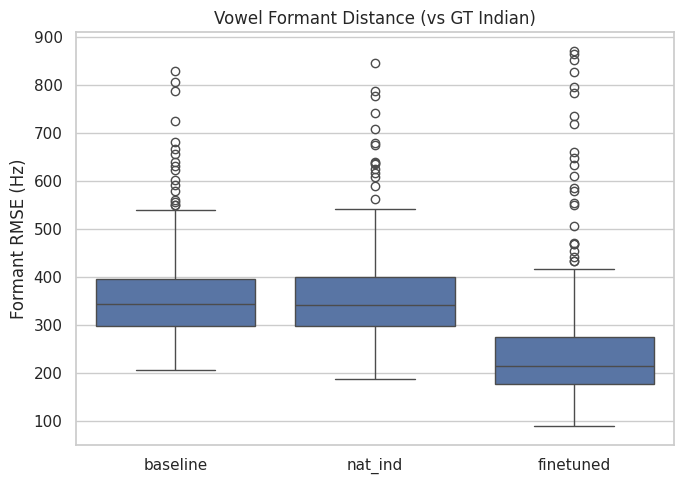

In [ ]:
plt.figure()
sns.boxplot(
    data=df_formant,
    x="system",
    y="formant_rmse",
    order=order
)

plt.title("Vowel Formant Distance (vs GT Indian)")
plt.ylabel("Formant RMSE (Hz)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("formant_boxplot.png", dpi=300)
plt.show()

PPG-DTW

In [ ]:
import torch
import librosa
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from fastdtw import fastdtw
import numpy as np

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
model.eval()

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [ ]:
# ✅ Modified: resample to 16k inside function
def extract_ppg(wav, sr=SR):

    # Resample to 16k if needed
    if sr != 16000:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=16000)
        sr = 16000

    inputs = processor(wav, sampling_rate=16000, return_tensors="pt")

    with torch.no_grad():
        out = model(**inputs)

    return out.last_hidden_state.squeeze(0).numpy()


def compute_ppg_dtw(ref_wav, syn_wav):

    ref_ppg = extract_ppg(ref_wav)
    syn_ppg = extract_ppg(syn_wav)

    dist, path = fastdtw(
        ref_ppg,
        syn_ppg,
        dist=lambda x,y: np.linalg.norm(x-y)
    )

    return dist / len(path)


In [ ]:
results_ppg = []

for file in gt_files:

    lj_id = file.replace(".wav","")

    ref_wav_path = os.path.join(GT_AUDIO_PATH, file)
    ref_audio = load_audio(ref_wav_path)

    for system in ["baseline","nat_ind","finetuned"]:

        if system == "nat_ind":
            syn_file = lj_id + "_s.wav"
        else:
            syn_file = lj_id + ".wav"

        syn_wav_path = os.path.join(AUDIO_SYSTEMS[system], syn_file)
        syn_audio = load_audio(syn_wav_path)

        val = compute_ppg_dtw(ref_audio, syn_audio)

        results_ppg.append({
            "system": system,
            "file": lj_id,
            "ppg_dtw": val
        })

df_ppg = pd.DataFrame(results_ppg)

In [ ]:
df_ppg.groupby("system")["ppg_dtw"].mean()

,ppg_dtw
system,
baseline,3.396466
finetuned,2.831758
nat_ind,3.315138


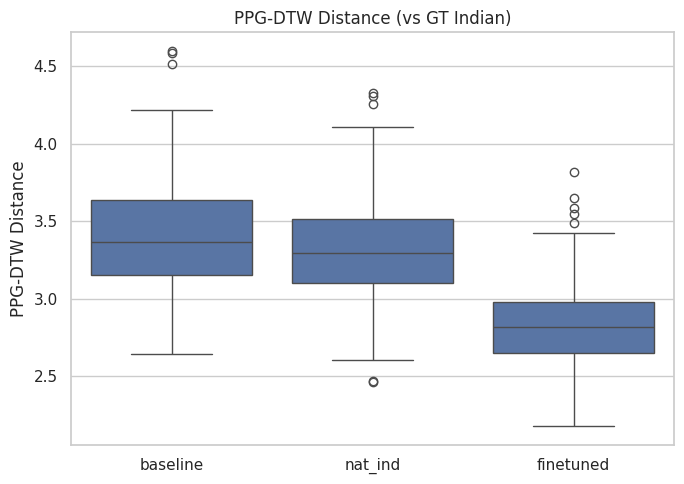

In [ ]:
plt.figure()
sns.boxplot(
    data=df_ppg,
    x="system",
    y="ppg_dtw",
    order=order
)

plt.title("PPG-DTW Distance (vs GT Indian)")
plt.ylabel("PPG-DTW Distance")
plt.xlabel("")
plt.tight_layout()
plt.savefig("ppg_boxplot.png", dpi=300)
plt.show()

PPG-DTW

### Embedding Space Analysis
- PCA plots at 30D - 2D s, sa, sp plots; silhouette scores
- cosine similarity heatmap
- centroid distance - plot or table

Verifying folder structure

In [ ]:
import os

ROOT_RESULTS = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/Results_finetuned"

STYLE_SYSTEMS = {
    "baseline": os.path.join(ROOT_RESULTS, "baseline_lj", "style_vectors"),
    "finetuned": os.path.join(ROOT_RESULTS, "spicor_full_no_slm", "style_vectors"),
}

print("===== CHECKING STYLE VECTOR FOLDERS =====")

for name, path in STYLE_SYSTEMS.items():
    print(f"\n--- {name.upper()} ---")
    print("Path exists:", os.path.exists(path))

    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.endswith(".pt")]
        print("Total .pt files:", len(files))

        # Check types
        s_files  = [f for f in files if f.endswith("_s.pt")]
        sa_files = [f for f in files if f.endswith("_sa.pt")]
        sp_files = [f for f in files if f.endswith("_sp.pt")]

        print("S vectors:", len(s_files))
        print("SA vectors:", len(sa_files))
        print("SP vectors:", len(sp_files))

        print("Example files:", files[:5])

===== CHECKING STYLE VECTOR FOLDERS =====

--- BASELINE ---
Path exists: True
Total .pt files: 714
S vectors: 238
SA vectors: 238
SP vectors: 238
Example files: ['LJ025-0065_sp.pt', 'LJ011-0268_s.pt', 'LJ010-0032_sa.pt', 'LJ026-0127_s.pt', 'LJ002-0126_s.pt']

--- FINETUNED ---
Path exists: True
Total .pt files: 714
S vectors: 238
SA vectors: 238
SP vectors: 238
Example files: ['LJ009-0281_sa.pt', 'LJ010-0180_sp.pt', 'LJ049-0201_sa.pt', 'LJ028-0447_sa.pt', 'LJ039-0142_s.pt']


In [ ]:
def get_lj_ids(path, suffix="_s.pt"):
    files = [f for f in os.listdir(path) if f.endswith(suffix)]
    return set([f.replace(suffix, "") for f in files])

baseline_ids  = get_lj_ids(STYLE_SYSTEMS["baseline"])
finetuned_ids = get_lj_ids(STYLE_SYSTEMS["finetuned"])

print("Baseline IDs:", len(baseline_ids))
print("Finetuned IDs:", len(finetuned_ids))

print("Missing in finetuned:", baseline_ids - finetuned_ids)
print("Missing in baseline:", finetuned_ids - baseline_ids)

Baseline IDs: 238
Finetuned IDs: 238
Missing in finetuned: set()
Missing in baseline: set()


In [ ]:
import torch
import numpy as np

def load_embeddings(system_path, suffix="_s.pt"):

    embeddings = []
    labels = []

    files = sorted([f for f in os.listdir(system_path) if f.endswith(suffix)])

    for f in files:
        path = os.path.join(system_path, f)
        emb = torch.load(path, map_location="cpu")

        if isinstance(emb, torch.Tensor):
            emb = emb.detach().cpu().numpy()

        embeddings.append(emb.flatten())
        labels.append(f.replace(suffix, ""))

    return np.array(embeddings), labels


# Load baseline and finetuned S vectors
baseline_s, ids = load_embeddings(STYLE_SYSTEMS["baseline"], "_s.pt")
finetuned_s, _ = load_embeddings(STYLE_SYSTEMS["finetuned"], "_s.pt")

print("Baseline S shape:", baseline_s.shape)
print("Finetuned S shape:", finetuned_s.shape)

Baseline S shape: (238, 256)
Finetuned S shape: (238, 256)


In [ ]:
baseline_s, ids = load_embeddings(STYLE_SYSTEMS["baseline"], "_sa.pt")
finetuned_s, _ = load_embeddings(STYLE_SYSTEMS["finetuned"], "_sa.pt")

print("Baseline S shape:", baseline_s.shape)
print("Finetuned S shape:", finetuned_s.shape)

Baseline S shape: (238, 128)
Finetuned S shape: (238, 128)


In [ ]:
baseline_s, ids = load_embeddings(STYLE_SYSTEMS["baseline"], "_sp.pt")
finetuned_s, _ = load_embeddings(STYLE_SYSTEMS["finetuned"], "_sp.pt")

print("Baseline S shape:", baseline_s.shape)
print("Finetuned S shape:", finetuned_s.shape)

Baseline S shape: (238, 128)
Finetuned S shape: (238, 128)


In [ ]:
import numpy as np

def inspect_embeddings(name, X):
    print(f"\n===== {name} =====")
    print("Shape:", X.shape)

    print("Min value:", np.min(X))
    print("Max value:", np.max(X))
    print("Mean:", np.mean(X))
    print("Std:", np.std(X))

    print("Any NaN:", np.isnan(X).any())
    print("Any Inf:", np.isinf(X).any())

    norms = np.linalg.norm(X, axis=1)
    print("Norm mean:", np.mean(norms))
    print("Norm std:", np.std(norms))
    print("Norm min:", np.min(norms))
    print("Norm max:", np.max(norms))


inspect_embeddings("Baseline S", baseline_s)
inspect_embeddings("Finetuned S", finetuned_s)


===== Baseline S =====
Shape: (238, 128)
Min value: -1.4194635
Max value: 1.441381
Mean: -0.023030225
Std: 0.33531043
Any NaN: False
Any Inf: False
Norm mean: 3.77906
Norm std: 0.42193618
Norm min: 2.9609997
Norm max: 5.2639728

===== Finetuned S =====
Shape: (238, 128)
Min value: -1.187545
Max value: 1.2520034
Mean: -0.03547919
Std: 0.36739144
Any NaN: False
Any Inf: False
Norm mean: 4.169269
Norm std: 0.23517536
Norm min: 3.4791737
Norm max: 4.965689


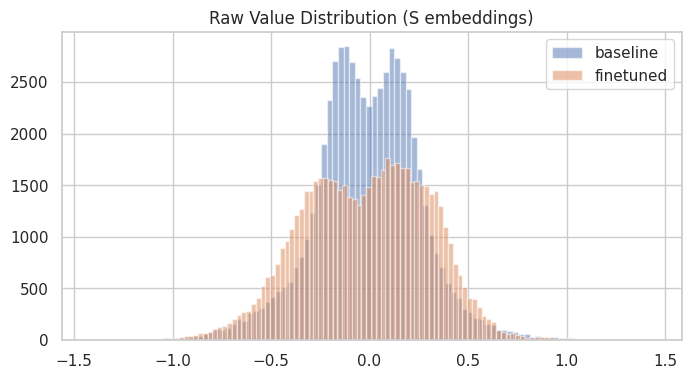

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(baseline_s.flatten(), bins=100, alpha=0.5, label="baseline")
plt.hist(finetuned_s.flatten(), bins=100, alpha=0.5, label="finetuned")
plt.legend()
plt.title("Raw Value Distribution (S embeddings)")
plt.show()

In [ ]:
baseline_var = np.var(baseline_s, axis=0)
finetuned_var = np.var(finetuned_s, axis=0)

print("Baseline zero-variance dims:", np.sum(baseline_var < 1e-8))
print("Finetuned zero-variance dims:", np.sum(finetuned_var < 1e-8))

Baseline zero-variance dims: 0
Finetuned zero-variance dims: 0


In [ ]:
baseline_sa, _ = load_embeddings(STYLE_SYSTEMS["baseline"], "_sa.pt")
finetuned_sa, _ = load_embeddings(STYLE_SYSTEMS["finetuned"], "_sa.pt")

inspect_embeddings("Baseline SA", baseline_sa)
inspect_embeddings("Finetuned SA", finetuned_sa)


baseline_sp, _ = load_embeddings(STYLE_SYSTEMS["baseline"], "_sp.pt")
finetuned_sp, _ = load_embeddings(STYLE_SYSTEMS["finetuned"], "_sp.pt")

inspect_embeddings("Baseline SP", baseline_sp)
inspect_embeddings("Finetuned SP", finetuned_sp)


===== Baseline SA =====
Shape: (238, 128)
Min value: -0.64324355
Max value: 0.76992416
Mean: 0.0005804836
Std: 0.17125025
Any NaN: False
Any Inf: False
Norm mean: 1.9326216
Norm std: 0.13721675
Norm min: 1.7046376
Norm max: 2.4978812

===== Finetuned SA =====
Shape: (238, 128)
Min value: -0.7035374
Max value: 0.82944
Mean: -0.0018439658
Std: 0.2599654
Any NaN: False
Any Inf: False
Norm mean: 2.9373722
Norm std: 0.15091418
Norm min: 2.610926
Norm max: 3.302354

===== Baseline SP =====
Shape: (238, 128)
Min value: -1.4194635
Max value: 1.441381
Mean: -0.023030225
Std: 0.33531043
Any NaN: False
Any Inf: False
Norm mean: 3.77906
Norm std: 0.42193618
Norm min: 2.9609997
Norm max: 5.2639728

===== Finetuned SP =====
Shape: (238, 128)
Min value: -1.187545
Max value: 1.2520034
Mean: -0.03547919
Std: 0.36739144
Any NaN: False
Any Inf: False
Norm mean: 4.169269
Norm std: 0.23517536
Norm min: 3.4791737
Norm max: 4.965689


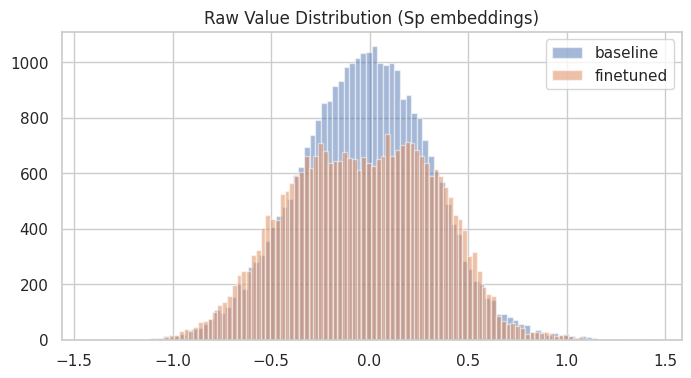

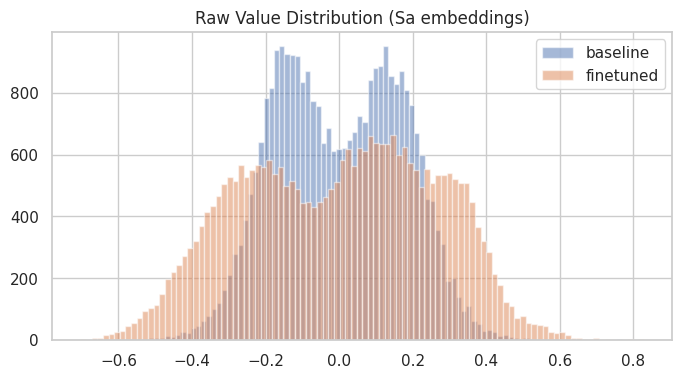

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(baseline_sp.flatten(), bins=100, alpha=0.5, label="baseline")
plt.hist(finetuned_sp.flatten(), bins=100, alpha=0.5, label="finetuned")
plt.legend()
plt.title("Raw Value Distribution (Sp embeddings)")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(baseline_sa.flatten(), bins=100, alpha=0.5, label="baseline")
plt.hist(finetuned_sa.flatten(), bins=100, alpha=0.5, label="finetuned")
plt.legend()
plt.title("Raw Value Distribution (Sa embeddings)")
plt.show()

PCA

In [ ]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt


def run_embedding_analysis(baseline, finetuned, name, pca_dim, use_standardization):

    print("\n====================================")
    print(f"{name} | PCA={pca_dim} | Standardize={use_standardization}")
    print("====================================")

    # Concatenate
    X = np.vstack([baseline, finetuned])
    labels = np.array([0]*len(baseline) + [1]*len(finetuned))

    # L2 normalize (always)
    X = normalize(X, norm="l2")

    # Optional standardization
    if use_standardization:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # PCA to chosen dimension
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X)

    # Silhouette score
    sil = silhouette_score(X_pca, labels)
    print("Silhouette score:", sil)

    # 2D PCA for visualization
    pca2 = PCA(n_components=2)
    X_2d = pca2.fit_transform(X)

    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[labels==0,0], X_2d[labels==0,1],
                alpha=0.6, label="baseline")
    plt.scatter(X_2d[labels==1,0], X_2d[labels==1,1],
                alpha=0.6, label="finetuned")

    plt.title(f"{name} | PCA{pca_dim} | Std={use_standardization}")
    plt.legend()
    plt.show()

    return sil


S | PCA=30 | Standardize=False
Silhouette score: 0.292013


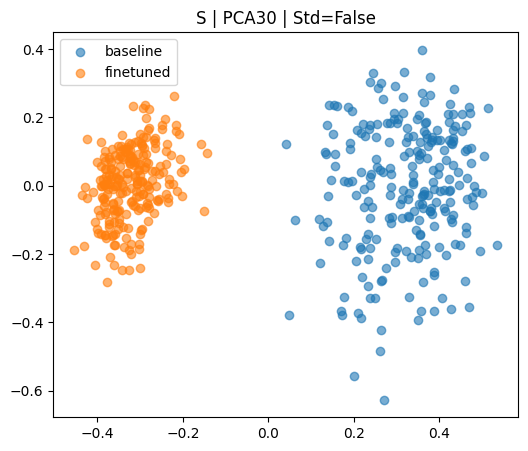


S | PCA=30 | Standardize=True
Silhouette score: 0.24342798


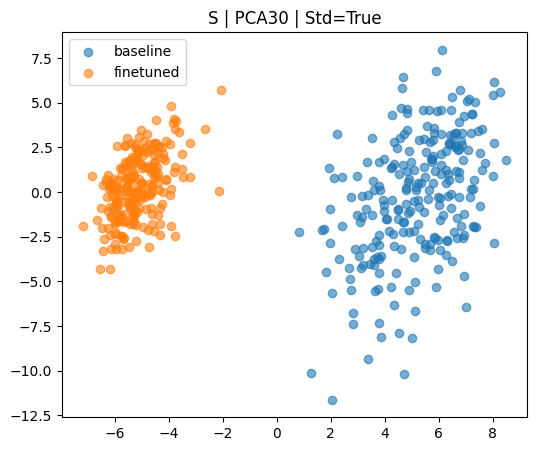


S | PCA=10 | Standardize=False
Silhouette score: 0.4033847


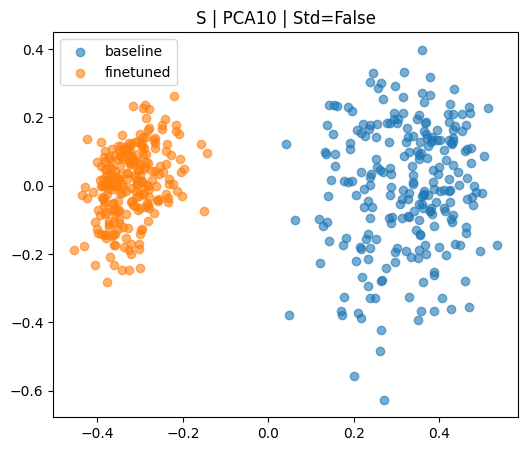


S | PCA=10 | Standardize=True
Silhouette score: 0.3505679


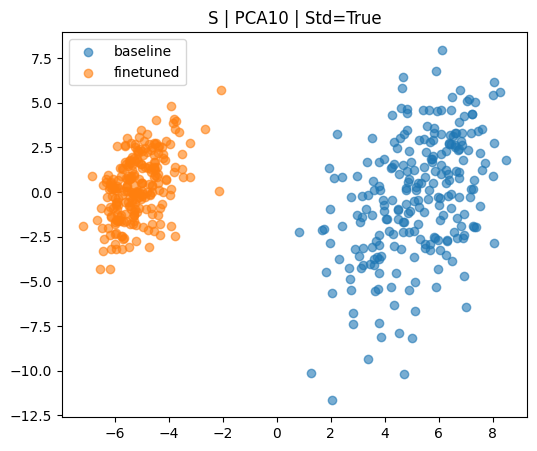


SA | PCA=30 | Standardize=False
Silhouette score: 0.48340297


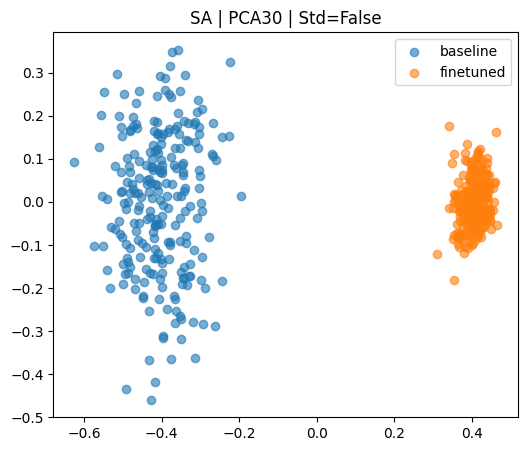


SA | PCA=30 | Standardize=True
Silhouette score: 0.39164996


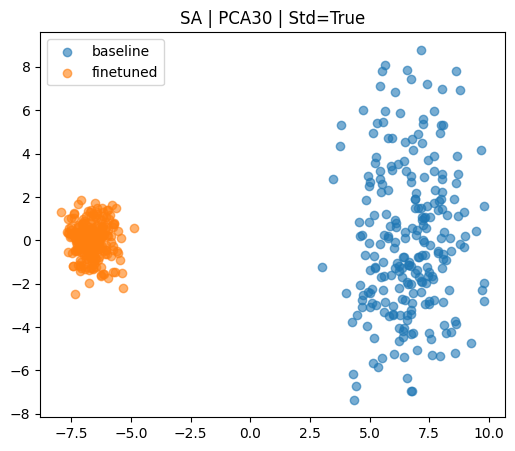


SA | PCA=10 | Standardize=False
Silhouette score: 0.5867285


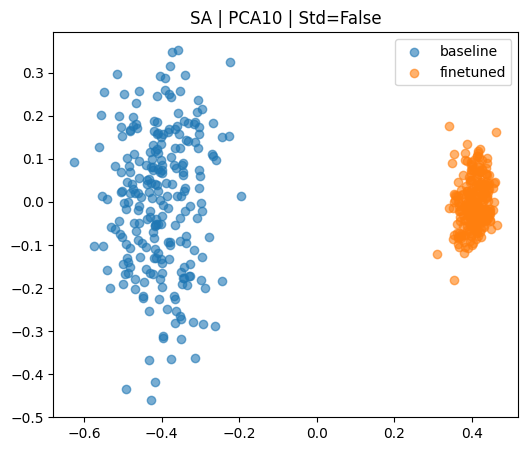


SA | PCA=10 | Standardize=True
Silhouette score: 0.5074461


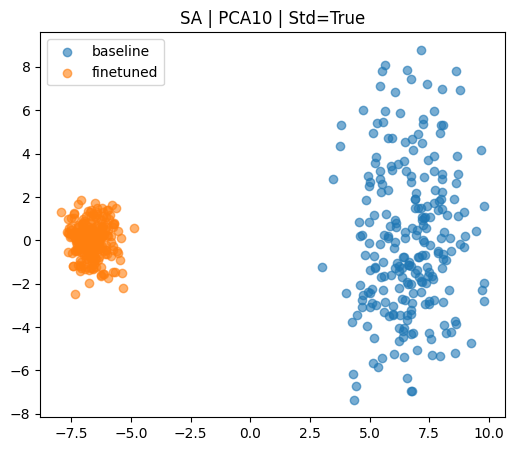


SP | PCA=30 | Standardize=False
Silhouette score: 0.292013


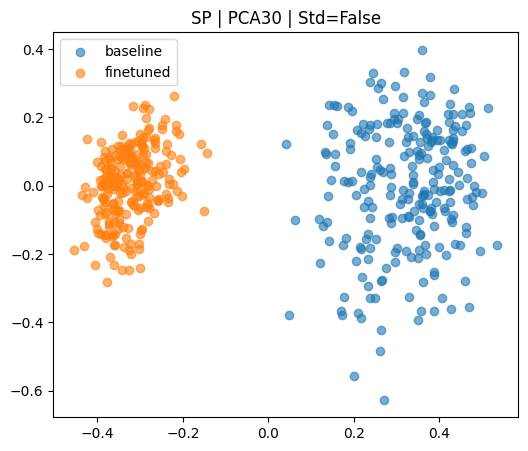


SP | PCA=30 | Standardize=True
Silhouette score: 0.24342798


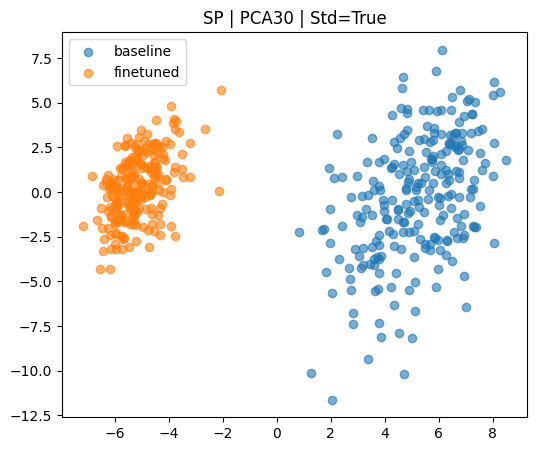


SP | PCA=10 | Standardize=False
Silhouette score: 0.4033847


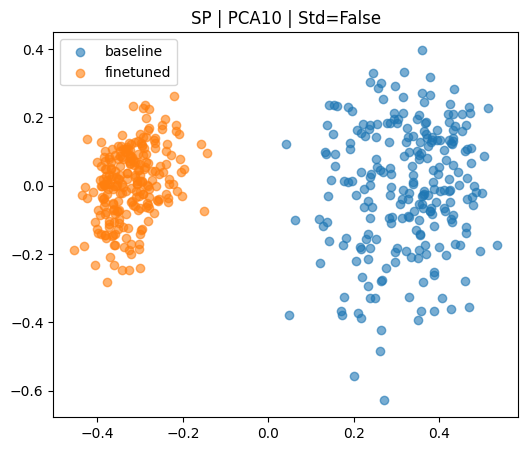


SP | PCA=10 | Standardize=True
Silhouette score: 0.3505679


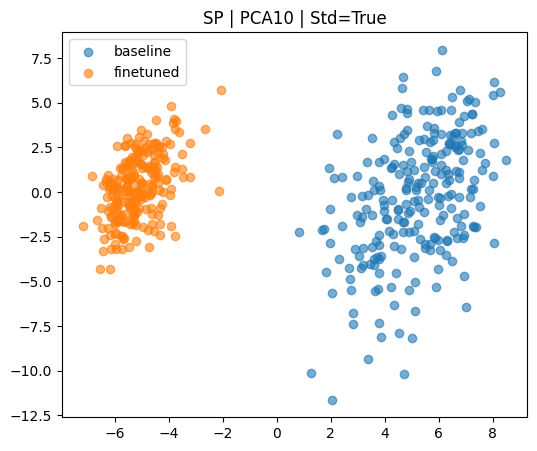

In [ ]:
results = {}

for name, base, ft in [
    ("S", baseline_s, finetuned_s),
    ("SA", baseline_sa, finetuned_sa),
    ("SP", baseline_sp, finetuned_sp)
]:

    for pca_dim in [30, 10]:
        for std in [False, True]:

            sil = run_embedding_analysis(
                base, ft,
                name=name,
                pca_dim=pca_dim,
                use_standardization=std
            )

            results[(name, pca_dim, std)] = sil

In [ ]:
print("\n===== FINAL SILHOUETTE SUMMARY =====\n")

for key, value in results.items():
    name, dim, std = key
    print(f"{name} | PCA={dim} | Std={std} -> {value}")


===== FINAL SILHOUETTE SUMMARY =====

S | PCA=30 | Std=False -> 0.3594186007976532
S | PCA=30 | Std=True -> 0.36398106813430786
S | PCA=10 | Std=False -> 0.4755025804042816
S | PCA=10 | Std=True -> 0.488085001707077
SA | PCA=30 | Std=False -> 0.48340296745300293
SA | PCA=30 | Std=True -> 0.3916499614715576
SA | PCA=10 | Std=False -> 0.5867285132408142
SA | PCA=10 | Std=True -> 0.5074461102485657
SP | PCA=30 | Std=False -> 0.2920129895210266
SP | PCA=30 | Std=True -> 0.24342797696590424
SP | PCA=10 | Std=False -> 0.4033846855163574
SP | PCA=10 | Std=True -> 0.35056790709495544


Cosine similarity

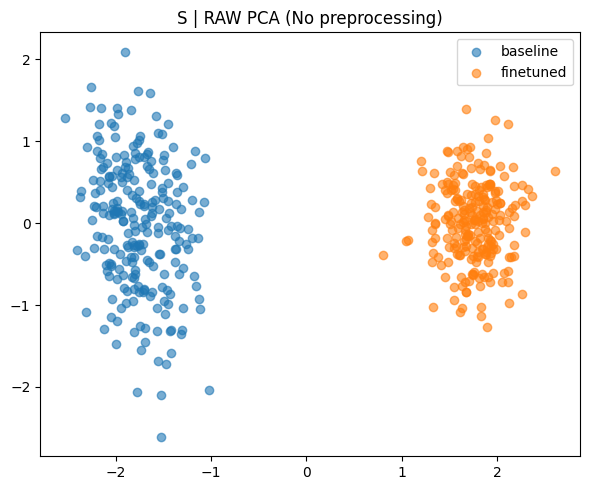

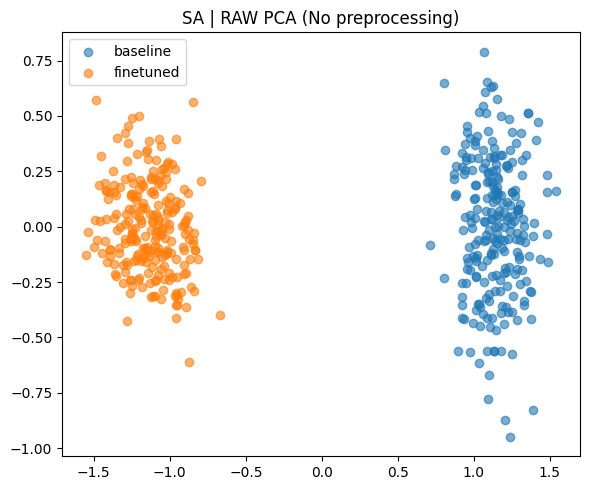

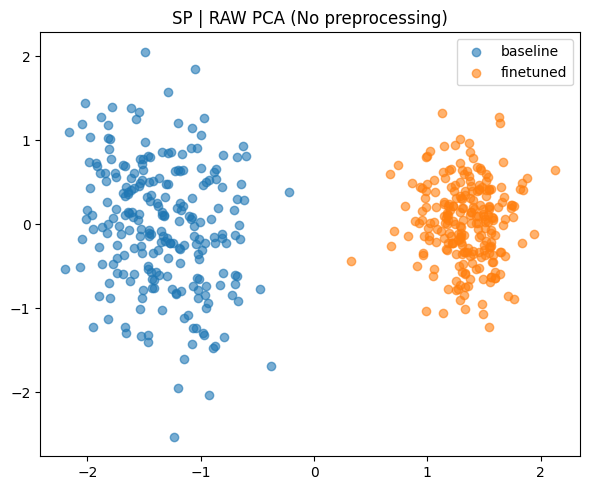

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 🔧 UPDATE THIS IF NEEDED
ROOT = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/Results_finetuned"

BASELINE_STYLE = os.path.join(ROOT, "baseline_lj", "style_vectors")
FINETUNED_STYLE = os.path.join(ROOT, "spicor_full_no_slm", "style_vectors")

def load_style_vectors(folder, suffix):
    files = sorted([f for f in os.listdir(folder) if f.endswith(suffix)])
    vectors = []

    for f in files:
        path = os.path.join(folder, f)
        vec = torch.load(path).numpy()
        vectors.append(vec)

    return np.vstack(vectors)


# Load raw embeddings
baseline_S  = load_style_vectors(BASELINE_STYLE, "_s.pt")
baseline_SA = load_style_vectors(BASELINE_STYLE, "_sa.pt")
baseline_SP = load_style_vectors(BASELINE_STYLE, "_sp.pt")

finetuned_S  = load_style_vectors(FINETUNED_STYLE, "_s.pt")
finetuned_SA = load_style_vectors(FINETUNED_STYLE, "_sa.pt")
finetuned_SP = load_style_vectors(FINETUNED_STYLE, "_sp.pt")

def raw_pca_plot(baseline, finetuned, name):

    X = np.vstack([baseline, finetuned])
    labels = np.array([0]*len(baseline) + [1]*len(finetuned))

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[labels==0,0], X_2d[labels==0,1],
                alpha=0.6, label="baseline")
    plt.scatter(X_2d[labels==1,0], X_2d[labels==1,1],
                alpha=0.6, label="finetuned")

    plt.title(f"{name} | RAW PCA (No preprocessing)")
    plt.legend()
    plt.tight_layout()
    plt.show()

raw_pca_plot(baseline_S,  finetuned_S,  "S")
raw_pca_plot(baseline_SA, finetuned_SA, "SA")
raw_pca_plot(baseline_SP, finetuned_SP, "SP")

Centroid distance

In [ ]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt


def run_pca30_standardized_fixed_axes(baseline, finetuned, name,
                                      xlim=None, ylim=None):

    print("\n====================================")
    print(f"{name} | PCA=30 | Standardized")
    print("====================================")

    X = np.vstack([baseline, finetuned])
    labels = np.array([0]*len(baseline) + [1]*len(finetuned))

    # L2 normalize
    X = normalize(X, norm="l2")

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # PCA 30D for metrics
    pca30 = PCA(n_components=30)
    X_pca30 = pca30.fit_transform(X)

    sil = silhouette_score(X_pca30, labels)

    c0 = np.mean(X_pca30[labels==0], axis=0)
    c1 = np.mean(X_pca30[labels==1], axis=0)

    centroid_dist = np.linalg.norm(c0 - c1)
    cos_sim = cosine_similarity([c0], [c1])[0][0]

    print("Silhouette:", sil)
    print("Centroid distance:", centroid_dist)
    print("Cosine similarity:", cos_sim)

    # PCA 2D for plotting
    pca2 = PCA(n_components=2)
    X_2d = pca2.fit_transform(X)

    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[labels==0,0], X_2d[labels==0,1],
                alpha=0.6, label="baseline")
    plt.scatter(X_2d[labels==1,0], X_2d[labels==1,1],
                alpha=0.6, label="finetuned")

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{name} | PCA")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return sil, centroid_dist, cos_sim, X_2d


S | PCA=30 | Standardized
Silhouette: 0.24342798
Centroid distance: 10.372687
Cosine similarity: -1.0000001


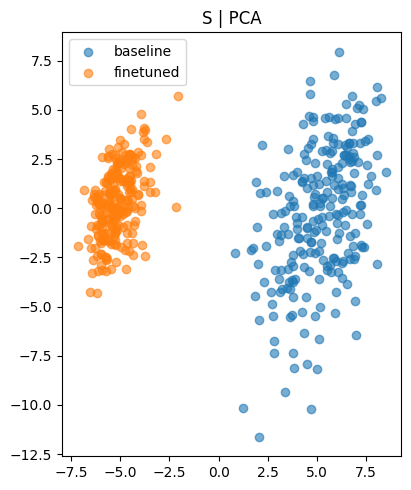


SA | PCA=30 | Standardized
Silhouette: 0.39164996
Centroid distance: 13.314703
Cosine similarity: -0.99999994


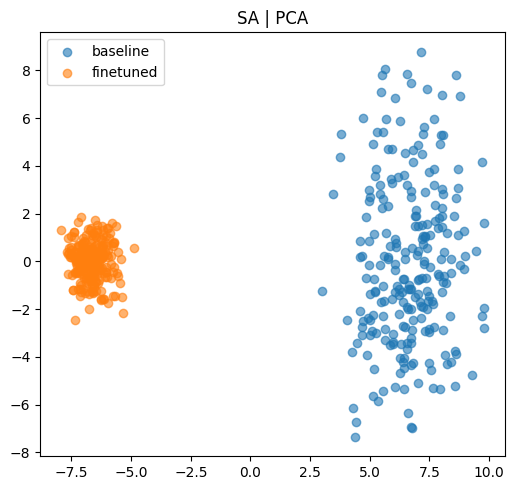


SP | PCA=30 | Standardized
Silhouette: 0.24342798
Centroid distance: 10.372687
Cosine similarity: -1.0000001


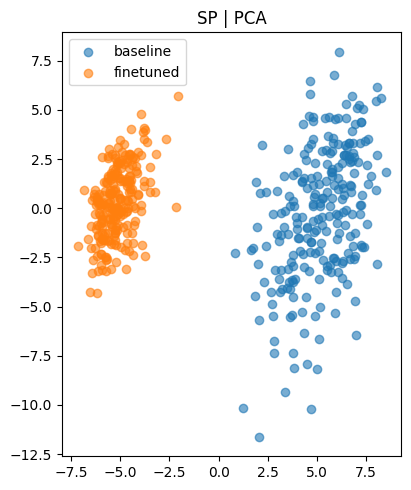

In [ ]:
sil_s, dist_s, cos_s, Xs = run_pca30_standardized_fixed_axes(baseline_s, finetuned_s, "S")
sil_sa, dist_sa, cos_sa, Xsa = run_pca30_standardized_fixed_axes(baseline_sa, finetuned_sa, "SA")
sil_sp, dist_sp, cos_sp, Xsp = run_pca30_standardized_fixed_axes(baseline_sp, finetuned_sp, "SP")

In [ ]:
all_X = np.vstack([Xs, Xsa, Xsp])

x_min, x_max = np.min(all_X[:,0]), np.max(all_X[:,0])
y_min, y_max = np.min(all_X[:,1]), np.max(all_X[:,1])

xlim = (x_min, x_max)
ylim = (y_min, y_max)

print("Global xlim:", xlim)
print("Global ylim:", ylim)

Global xlim: (np.float32(-7.9228044), np.float32(9.798375))
Global ylim: (np.float32(-11.627646), np.float32(8.790171))



S | PCA=30 | Standardized
Silhouette: 0.24342798
Centroid distance: 10.372687
Cosine similarity: -1.0000001


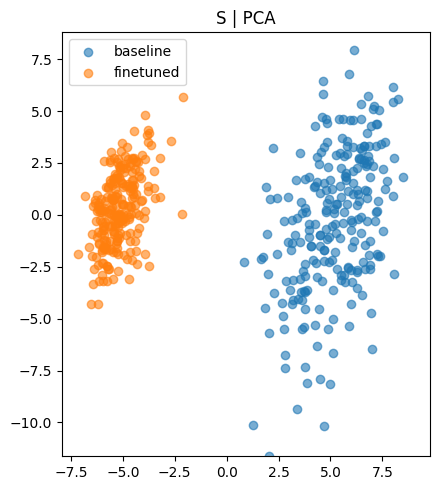


SA | PCA=30 | Standardized
Silhouette: 0.39164996
Centroid distance: 13.314703
Cosine similarity: -0.99999994


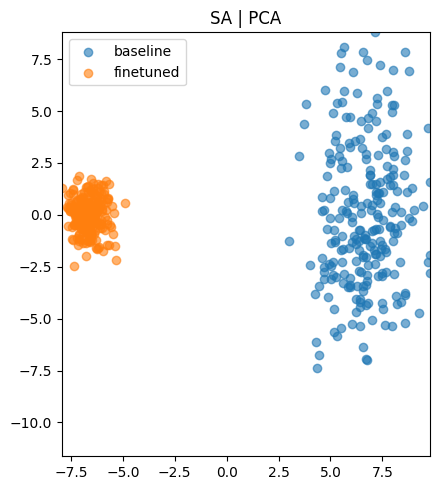


SP | PCA=30 | Standardized
Silhouette: 0.24342798
Centroid distance: 10.372687
Cosine similarity: -1.0000001


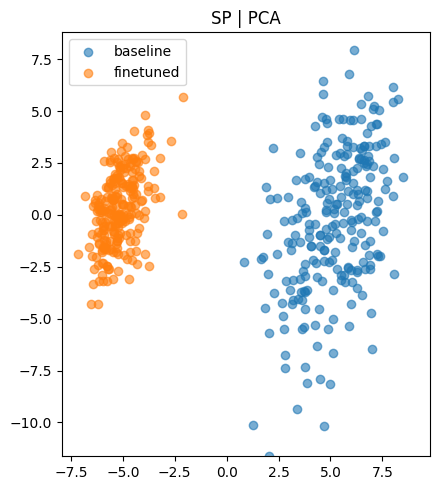

(np.float32(0.24342798),
 np.float32(10.372687),
 np.float32(-1.0000001),
 array([[ 8.01389885e+00,  9.24324512e-01],
        [ 7.38022280e+00, -1.96616960e+00],
        [ 7.53805447e+00,  2.19600725e+00],
        [ 5.58823061e+00, -3.84623408e-01],
        [ 5.74363852e+00,  1.82244408e+00],
        [ 6.87901402e+00,  2.61421847e+00],
        [ 4.27826214e+00,  4.29568958e+00],
        [ 7.21878099e+00,  4.39634943e+00],
        [ 5.07509851e+00, -5.22068381e-01],
        [ 3.78862309e+00, -2.94946432e+00],
        [ 3.77849579e+00,  3.44153881e-01],
        [ 6.76293564e+00,  3.93085265e+00],
        [ 6.58557177e+00, -2.24883151e+00],
        [ 8.06266212e+00,  2.72642136e+00],
        [ 6.49167585e+00,  5.32283974e+00],
        [ 4.33114338e+00, -2.99307108e+00],
        [ 2.22039199e+00,  3.22860885e+00],
        [ 4.80857992e+00,  4.63406801e+00],
        [ 8.26088333e+00,  5.59680700e+00],
        [ 5.88323975e+00,  6.79376507e+00],
        [ 5.27743387e+00, -8.63954961e-01],
  

In [ ]:
run_pca30_standardized_fixed_axes(baseline_s, finetuned_s, "S", xlim, ylim)
run_pca30_standardized_fixed_axes(baseline_sa, finetuned_sa, "SA", xlim, ylim)
run_pca30_standardized_fixed_axes(baseline_sp, finetuned_sp, "SP", xlim, ylim)

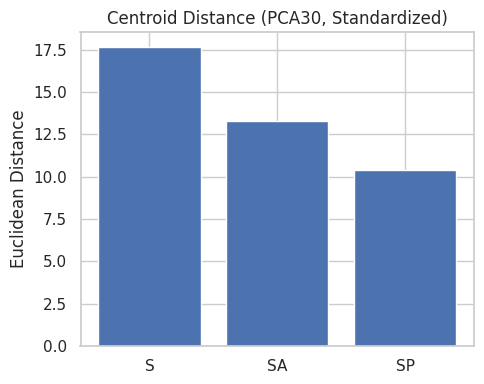

In [ ]:
centroid_distances = {
    "S": dist_s,
    "SA": dist_sa,
    "SP": dist_sp
}

plt.figure(figsize=(5,4))
plt.bar(centroid_distances.keys(),
        centroid_distances.values())

plt.title("Centroid Distance (PCA30, Standardized)")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

Better plots

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 🔧 EDIT ROOT IF NEEDED
ROOT = "/content/drive/MyDrive/Namrata-IMP-Docs/IIITH/Research/Results_finetuned"

BASELINE_PATH = os.path.join(ROOT, "baseline_lj", "style_vectors")
FINETUNED_PATH = os.path.join(ROOT, "spicor_full_no_slm", "style_vectors")


def load_vectors(folder, suffix):
    files = sorted([f for f in os.listdir(folder) if f.endswith(suffix)])
    vectors = []
    for f in files:
        vec = torch.load(os.path.join(folder, f)).numpy()
        vectors.append(vec)
    return np.vstack(vectors)


baseline_S  = load_vectors(BASELINE_PATH, "_s.pt")
baseline_SA = load_vectors(BASELINE_PATH, "_sa.pt")
baseline_SP = load_vectors(BASELINE_PATH, "_sp.pt")

finetuned_S  = load_vectors(FINETUNED_PATH, "_s.pt")
finetuned_SA = load_vectors(FINETUNED_PATH, "_sa.pt")
finetuned_SP = load_vectors(FINETUNED_PATH, "_sp.pt")

In [ ]:
def run_full_pipeline(baseline, finetuned):

    X = np.vstack([baseline, finetuned])
    labels = np.array([0]*len(baseline) + [1]*len(finetuned))

    # L2 normalize
    X = normalize(X, norm="l2")

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # PCA 30D
    pca30 = PCA(n_components=30)
    X_pca30 = pca30.fit_transform(X)

    # Metrics
    sil = silhouette_score(X_pca30, labels)

    c0 = np.mean(X_pca30[labels==0], axis=0)
    c1 = np.mean(X_pca30[labels==1], axis=0)
    centroid_dist = np.linalg.norm(c0 - c1)

    # PCA 2D for plotting
    pca2 = PCA(n_components=2)
    X_2d = pca2.fit_transform(X)

    return sil, centroid_dist, X_2d, labels

In [ ]:
sil_S,  dist_S,  X2_S,  labels_S  = run_full_pipeline(baseline_S,  finetuned_S)
sil_SA, dist_SA, X2_SA, labels_SA = run_full_pipeline(baseline_SA, finetuned_SA)
sil_SP, dist_SP, X2_SP, labels_SP = run_full_pipeline(baseline_SP, finetuned_SP)

print("Silhouette:")
print("S :", sil_S)
print("SA:", sil_SA)
print("SP:", sil_SP)

print("\nCentroid distances:")
print("S :", dist_S)
print("SA:", dist_SA)
print("SP:", dist_SP)

Silhouette:
S : 0.36398107
SA: 0.39164996
SP: 0.24342798

Centroid distances:
S : 17.644873
SA: 13.314703
SP: 10.372687


In [ ]:
# Combine all PCA2 projections
all_points = np.vstack([X2_S, X2_SA, X2_SP])

x_min, x_max = np.min(all_points[:,0]), np.max(all_points[:,0])
y_min, y_max = np.min(all_points[:,1]), np.max(all_points[:,1])

def round_to_10(min_val, max_val):
    lower = np.floor(min_val/10)*10
    upper = np.ceil(max_val/10)*10
    return (lower, upper)

xlim = round_to_10(x_min, x_max)
ylim = round_to_10(y_min, y_max)

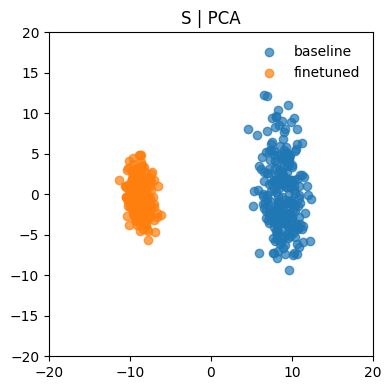

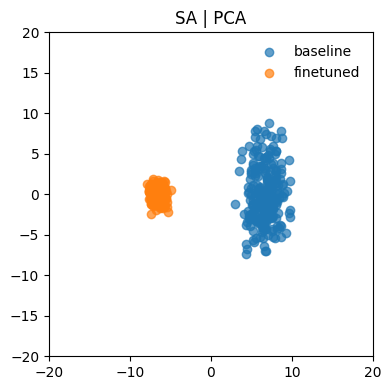

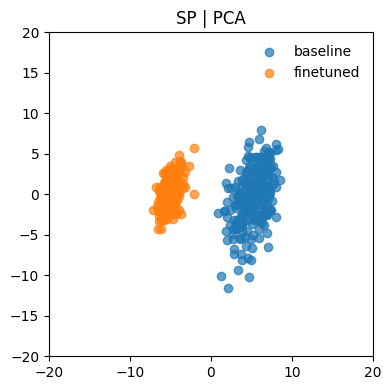

In [ ]:
def clean_plot(X2, labels, title):

    plt.figure(figsize=(5,4))

    plt.scatter(X2[labels==0,0], X2[labels==0,1],
                alpha=0.7, label="baseline")
    plt.scatter(X2[labels==1,0], X2[labels==1,1],
                alpha=0.7, label="finetuned")

    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(False)
    plt.legend(frameon=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


clean_plot(X2_S,  labels_S,  "S | PCA")
clean_plot(X2_SA, labels_SA, "SA | PCA")
clean_plot(X2_SP, labels_SP, "SP | PCA")

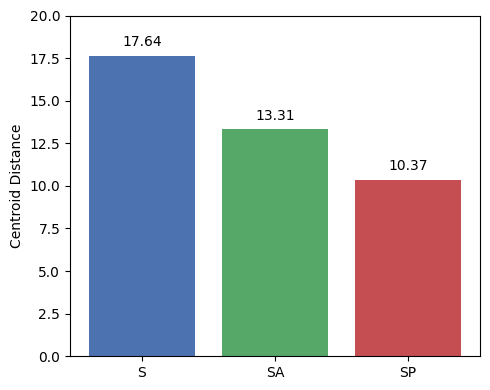

In [ ]:
distances = [dist_S, dist_SA, dist_SP]
labels_bar = ["S", "SA", "SP"]

y_max = np.ceil(max(distances)/10)*10

plt.figure(figsize=(5,4))
bars = plt.bar(labels_bar, distances,
               color=["#4C72B0", "#55A868", "#C44E52"])

plt.ylim(0, y_max)
plt.grid(False)
plt.ylabel("Centroid Distance")

for bar, val in zip(bars, distances):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + y_max*0.02,
             f"{val:.2f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()